**Ujian Tengah Semester Mata Kuliah Data Mining**

Nama: Zafira Anwar

NIM: 2304020049

# **IMPORT LIBRARY**

Pada tahap ini dilakukan import library yang akan digunakan selama proses analisis data mining, mulai dari preprocessing data, visualisasi, pembuatan model klasifikasi, evaluasi model, hingga export hasil prediksi.

In [115]:
# Library utama pengolahan data
import pandas as pd
import numpy as np

# Library visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library preprocessing dan modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model klasifikasi
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluasi model
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Menghilangkan warning
import warnings
warnings.filterwarnings('ignore')

# **LOAD DATASET**

Tahapan ini digunakan untuk membaca dataset training dan testing yang telah diberikan.

Dataset training memiliki variabel target yaitu quality, sedangkan dataset testing tidak memiliki variabel target karena nantinya akan diprediksi menggunakan model yang telah dibuat.

In [116]:
# Membaca dataset training
train = pd.read_csv('/content/data_training.csv')

# Membaca dataset testing
test = pd.read_csv('/content/data_testing.csv')

# **DATA AWAL**

Tahapan ini bertujuan untuk melihat isi dataset dan memastikan data berhasil dibaca dengan benar.

In [117]:
# Menampilkan 5 data pertama training
train.head()

# Menampilkan 5 data pertama testing
test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


# **INFORMASI DATASET**

Tahapan ini digunakan untuk mengetahui jumlah baris & kolom, tipe data, juml;ah data non-null, serta struktur dataset

In [118]:
# Informasi dataset training
train.info()

# Informasi dataset testing
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data c

# **UKURAN DATASET**

Tahapan ini digunakan untuk mengetahui jumlah data dan jumlah fitur pada dataset.

In [119]:
print("Ukuran dataset training:", train.shape)
print("Ukuran dataset testing:", test.shape)

Ukuran dataset training: (857, 13)
Ukuran dataset testing: (286, 12)


# **STATISTIK DESKRIPTIF**

Tahapan ini digunakan untuk melihat ringkasan statistik dari setiap variabel numerik seperti mean, standar deviasi, nilai minimum, dan nilai maksimum

In [120]:
train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


# **MENGECEK MISSING VALUE**

Tahapan preprocessing pertama adalah mengecek apakah terdapat missing value pada dataset.

In [121]:
# Mengecek missing value training
train.isnull().sum()

# Mengecek missing value testing
test.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Interpretasi Missing Value:

Setelah dilakukan pengecekan, hasil menunjukkan nilai 0 pada seluruh kolom, maka dataset tidak memiliki missing value.

# **DATA DUPLIKAT**

Jika terdapat data duplikat, maka data tersebut dapat dihapus agar tidak mempengaruhi performa model.

In [122]:
# Menghapus data duplikat
train = train.drop_duplicates()

# **DISTRIBUSI VARIABEL TARGET**

Tahapan ini bertujuan untuk melihat distribusi nilai quality pada dataset.

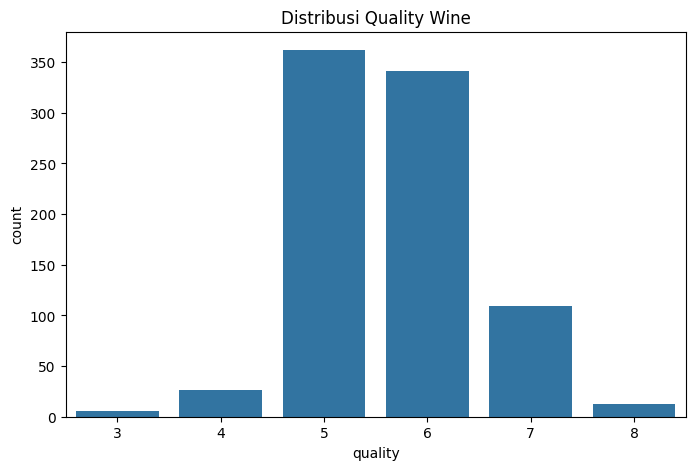

In [123]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=train)
plt.title('Distribusi Quality Wine')
plt.show()

Interpretasi Distribusi Target:


Visualisasi distribusi quality digunakan untuk mengetahui apakah distribusi kelas seimbang atau tidak.

Terlihat terdapat kelas yang jumlahnya jauh lebih sedikit dibanding kelas lain, maka dataset dapat dikatakan tidak seimbang.

# **KORELASI ANTAR VARIABEL**

Tahapan ini digunakan untuk melihat hubungan antar fitur numerik.

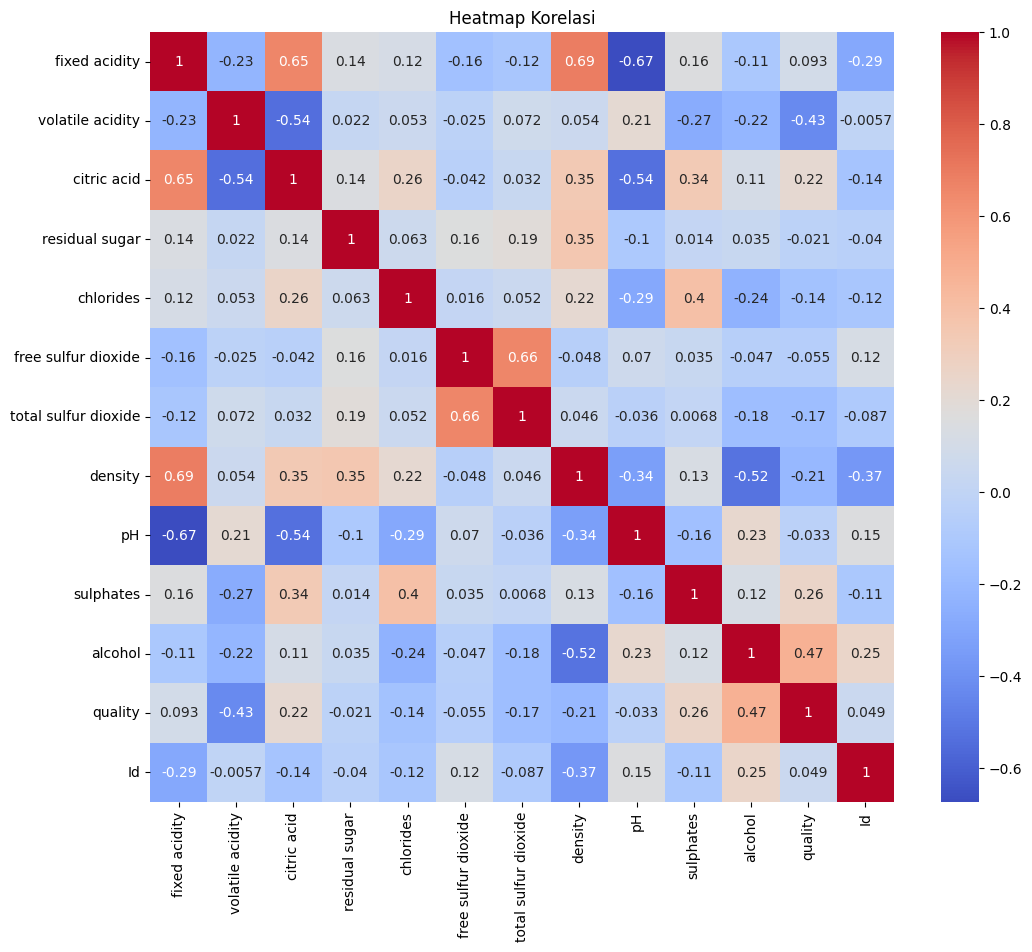

In [124]:
plt.figure(figsize=(12,10))
sns.heatmap(train.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

Interpretasi Korelasi:

Heatmap korelasi digunakan untuk mengetahui fitur yang memiliki hubungan kuat terhadap variabel quality.

Nilai korelasi mendekati:


*   1 → hubungan positif kuat
*   -1 → hubungan negatif kuat
*   0 → hubungan lemah






# **FEATURE DAN TARGET**

Tahapan ini digunakan untuk memisahkan fitur input (X) dan variabel target (y).
Variabel target yang diprediksi adalah quality.

In [125]:
# Memisahkan feature dan target
X = train.drop('quality', axis=1)
y = train['quality']

In [126]:
X.columns

print(X.columns.tolist())

for col in X.columns:
    print(col)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']
fixed acidity
volatile acidity
citric acid
residual sugar
chlorides
free sulfur dioxide
total sulfur dioxide
density
pH
sulphates
alcohol
Id


# **FEATURE SCALING**

Tahapan preprocessing selanjutnya adalah normalisasi data menggunakan StandardScaler.

Feature scaling penting dilakukan karena setiap fitur memiliki rentang nilai yang berbeda.

In [127]:
# Membuat scaler
scaler = StandardScaler()

# Fit dan transform data training
X_scaled = scaler.fit_transform(X)

# Transform data testing
X_test_scaled = scaler.transform(test)

Feature scaling dilakukan agar seluruh fitur memiliki skala yang seimbang sehingga model klasifikasi dapat bekerja lebih optimal.

# **TRAIN TEST SPLIT**

Tahapan ini digunakan untuk membagi dataset menjadi data training dan data validation/testing internal

In [128]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **MODEL LOGISTIC REGRESSION**

Model pertama yang digunakan adalah Logistic Regression.

In [129]:
# Membuat model logistic regression
logreg = LogisticRegression(max_iter=500)

# Training model
logreg.fit(X_train, y_train)

# Prediksi
pred_logreg = logreg.predict(X_val)

In [130]:
# Accuracy
acc_logreg = accuracy_score(y_val, pred_logreg)
print("Accuracy Logistic Regression:", acc_logreg)

# Confusion matrix
cm_logreg = confusion_matrix(y_val, pred_logreg)
print(cm_logreg)

# Classification report
print(classification_report(y_val, pred_logreg))

Accuracy Logistic Regression: 0.5988372093023255
[[ 0  0  1  0  0  0]
 [ 0  0  4  1  0  0]
 [ 0  1 56 16  0  0]
 [ 0  0 24 40  4  0]
 [ 0  0  0 15  7  0]
 [ 0  0  0  2  1  0]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.66      0.77      0.71        73
           6       0.54      0.59      0.56        68
           7       0.58      0.32      0.41        22
           8       0.00      0.00      0.00         3

    accuracy                           0.60       172
   macro avg       0.30      0.28      0.28       172
weighted avg       0.57      0.60      0.58       172



# **VISUALISASI CONFUSION MATRIX LOGISTIC REGRESSION**

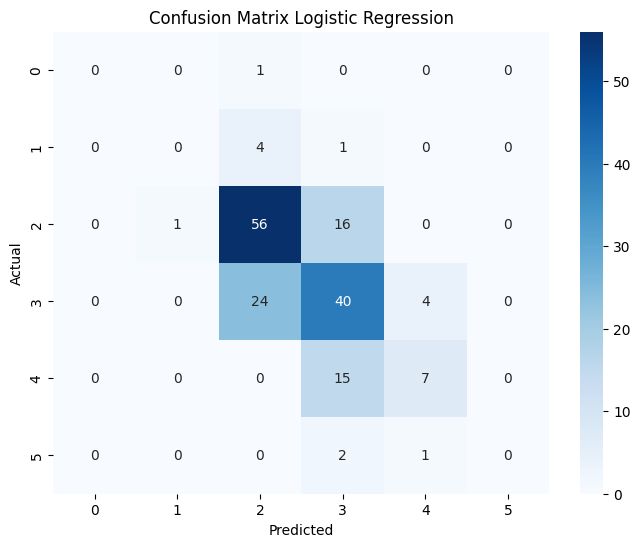

In [131]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Interpretasi Logistic Regression:
Nilai accuracy menunjukkan seberapa baik model dalam memprediksi kualitas wine.

Semakin tinggi accuracy, maka performa model semakin baik.

# **MODEL K-NEAREST NEIGHBOUR (KNN)**

Model kedua yang digunakan adalah KNN.

In [132]:
# Membuat model KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Training model
knn.fit(X_train, y_train)

# Prediksi
pred_knn = knn.predict(X_val)

In [133]:
# Accuracy
acc_knn = accuracy_score(y_val, pred_knn)
print("Accuracy KNN:", acc_knn)

# Confusion matrix
cm_knn = confusion_matrix(y_val, pred_knn)
print(cm_knn)

# Classification report
print(classification_report(y_val, pred_knn))

Accuracy KNN: 0.48255813953488375
[[ 0  0  0  1  0  0]
 [ 0  0  4  1  0  0]
 [ 0  2 43 28  0  0]
 [ 0  0 32 30  6  0]
 [ 0  0  2 10 10  0]
 [ 0  0  0  1  2  0]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.53      0.59      0.56        73
           6       0.42      0.44      0.43        68
           7       0.56      0.45      0.50        22
           8       0.00      0.00      0.00         3

    accuracy                           0.48       172
   macro avg       0.25      0.25      0.25       172
weighted avg       0.46      0.48      0.47       172



# **VISUALISASI CONFUSION MATRIX KNN**

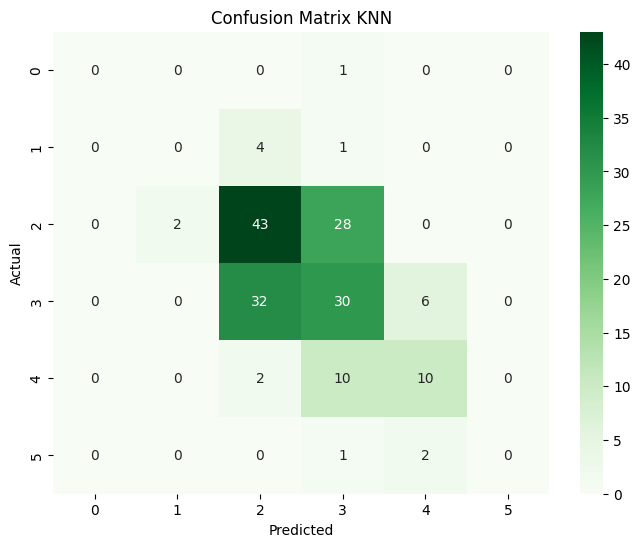

In [134]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **MODEL DECISION TREE**

Model ketiga yang digunakan adalah Decision Tree.

In [135]:
# Membuat model decision tree
DT = DecisionTreeClassifier(random_state=42)

# Training model
DT.fit(X_train, y_train)

# Prediksi
pred_dt = DT.predict(X_val)

In [136]:
# Accuracy
acc_dt = accuracy_score(y_val, pred_dt)
print("Accuracy Decision Tree:", acc_dt)

# Confusion matrix
cm_dt = confusion_matrix(y_val, pred_dt)
print(cm_dt)

# Classification report
print(classification_report(y_val, pred_dt))

Accuracy Decision Tree: 0.5465116279069767
[[ 0  0  0  1  0  0]
 [ 2  0  1  2  0  0]
 [ 2  5 49 11  6  0]
 [ 0  1 22 34  9  2]
 [ 0  1  4  7 10  0]
 [ 0  0  0  1  1  1]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.64      0.67      0.66        73
           6       0.61      0.50      0.55        68
           7       0.38      0.45      0.42        22
           8       0.33      0.33      0.33         3

    accuracy                           0.55       172
   macro avg       0.33      0.33      0.33       172
weighted avg       0.57      0.55      0.56       172



# VISUALISASI CONFUSION MATRIX DECISION TREE

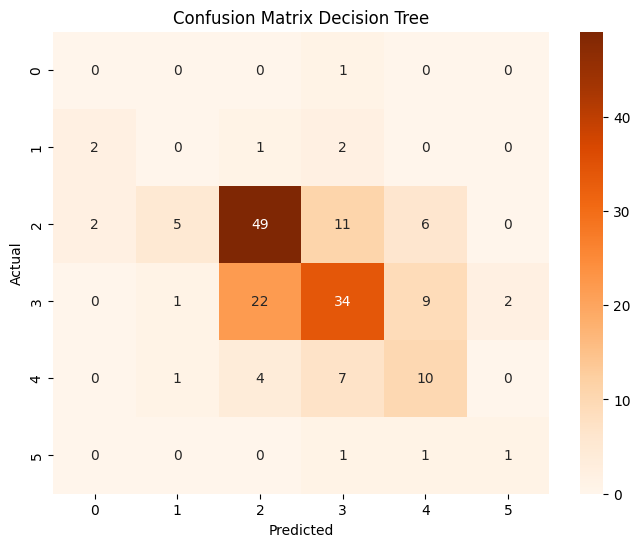

In [137]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **MODEL RANDOM FOREST**

Model keempat yang digunakan adalah Random Forest.

Random Forest dipilih karena memiliki performa yang baik untuk data klasifikasi numerik.

In [138]:
# Membuat model random forest
RF = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Training model
RF.fit(X_train, y_train)

# Prediksi
pred_rf = RF.predict(X_val)

In [139]:
# Accuracy
acc_rf = accuracy_score(y_val, pred_rf)
print("Accuracy Random Forest:", acc_rf)

# Confusion matrix
cm_rf = confusion_matrix(y_val, pred_rf)
print(cm_rf)

# Classification report
print(classification_report(y_val, pred_rf))

Accuracy Random Forest: 0.5930232558139535
[[ 0  0  0  1  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0 52 20  1  0]
 [ 0  0 23 41  4  0]
 [ 0  0  1 13  8  0]
 [ 0  0  0  0  2  1]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.64      0.71      0.68        73
           6       0.55      0.60      0.57        68
           7       0.53      0.36      0.43        22
           8       1.00      0.33      0.50         3

    accuracy                           0.59       172
   macro avg       0.45      0.34      0.36       172
weighted avg       0.57      0.59      0.58       172



# **VISUALISASI CONFUSION MATRIX RANDOM FOREST**

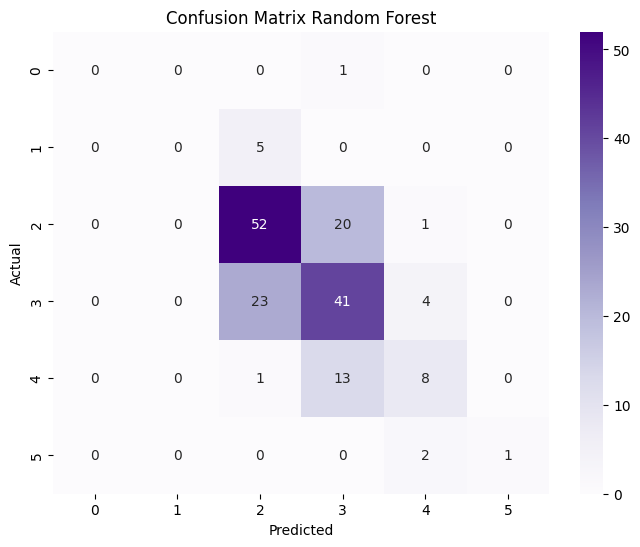

In [140]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **PREBANDINGAN ACCURACY SEMUA MODEL**

Tahapan ini digunakan untuk membandingkan performa seluruh model klasifikasi.

In [141]:
hasil_akurasi = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        acc_logreg,
        acc_knn,
        acc_dt,
        acc_rf
    ]
})

hasil_akurasi

,Model,Accuracy
0,Logistic Regression,0.598837
1,KNN,0.482558
2,Decision Tree,0.546512
3,Random Forest,0.593023


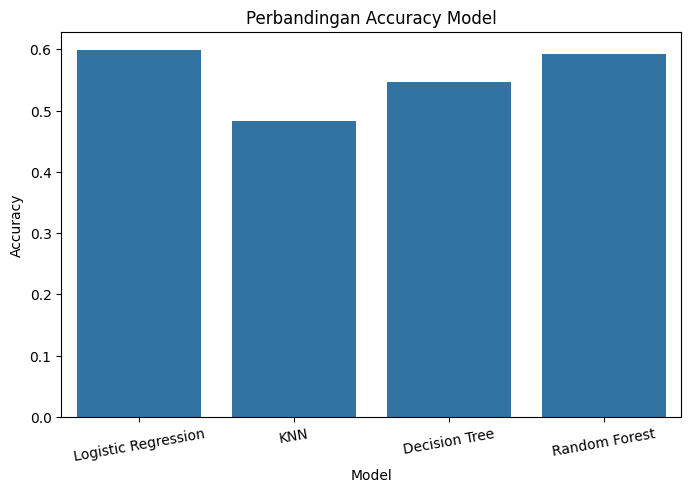

In [142]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Model',
    y='Accuracy',
    data=hasil_akurasi
)

plt.title('Perbandingan Accuracy Model')
plt.xticks(rotation=10)
plt.show()

Interpretasi Perbandingan Model:
Model dengan accuracy tertinggi dipilih sebagai model terbaik untuk melakukan prediksi pada dataset testing.

# **PREDIKSI DATA TESTING**

Pada tahap ini dilakukan prediksi nilai kualitas wine (quality) pada dataset testing menggunakan model terbaik yang telah diperoleh dari proses klasifikasi sebelumnya.

Model yang digunakan untuk prediksi adalah model dengan nilai accuracy tertinggi.

In [143]:
# Melakukan prediksi pada data testing
hasil_prediksi = RF.predict(X_test_scaled)

In [144]:
# Menampilkan 10 hasil prediksi pertama
hasil_prediksi[:10]

array([6, 6, 5, 5, 5, 6, 6, 5, 6, 5])

# **DATAFRAME SUBMISSION**

Tahapan ini digunakan untuk membuat file submission sesuai format yang diminta pada soal UTS.

In [145]:
# Membuat dataframe submission
submission = pd.DataFrame({
    'Id': test['Id'],
    'Quality': hasil_prediksi
})

# Menampilkan data submission
submission.head()

,Id,Quality
0,222,6
1,1514,6
2,417,5
3,754,5
4,516,5


Interpretasi Hasil Submission:
DataFrame submission berisi kolom Id sebagai identitas data testing, serta kolom Quality sebagai hasil prediksi kualitas wine dari model klasifikasi.


# **MENYIMPAN HASIL PREDIKSI**

Tahapan ini digunakan untuk menyimpan hasil prediksi ke dalam format CSV sesuai ketentuan pengumpulan.

In [146]:
# Menyimpan hasil prediksi ke file CSV
submission.to_csv(
    'hasilprediksi_049.csv',
    sep=';',
    index=False
)

In [147]:
submission.to_csv(
    'hasilprediksi_049.csv',
    sep=';',
    index=False
)

In [148]:
from google.colab import files

files.download('hasilprediksi_049.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [149]:
# Menyimpan hasil prediksi ke file Excel
submission.to_excel(
    'hasilprediksi_049.xlsx',
    index=False
)

In [150]:
from google.colab import files

files.download('hasilprediksi_049.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **KESIMPULAN**

Berdasarkan proses data mining yang telah dilakukan, model klasifikasi berhasil digunakan untuk memprediksi kualitas wine berdasarkan karakteristik kimiawi yang dimiliki setiap sampel wine.

Tahapan analisis dimulai dari preprocessing data, pengecekan missing value, penghapusan data duplikat, feature scaling, hingga proses klasifikasi menggunakan beberapa algoritma machine learning.

Model dengan performa terbaik dipilih untuk melakukan prediksi pada dataset testing. Hasil prediksi kemudian disimpan dalam format CSV dan xlsx.